# API Scraping Steam: Do Newer Games Receive More Positive User Reviews?

Vicky Wu    
ECO 590    
Spring 2026

## This notebook contains the code of API-scraping Steam data and Graphs.

## Motivation:
For this project I would be examining whether newer games on steam have a higher likelihood of receiving positive user reviews than older Steam games. Using the Steam data I have API scraped, to analyze how user review scores vary across the different years and the genres. Since my goal is to see what player interest are over the course of year and whether or not there are genres tend to receive higher ratings than others.

## Research Questions
1. How have Steam user review scores changed across different release periods?  

2. Do certain game genres tend to receive higher positive review scores than others?


# Part 1: API Scraping Steam

In [19]:
# packages needed
import requests
import csv
import time
import json
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [20]:
# Store the SteamSpy API URL in a variable
# This URL can be used to get Steam game data from SteamSpy
STEAMSPY_URL = "https://steamspy.com/api.php"

# Store the Steam Store API URL in a variable
# This URL is used to get game details from the Steam store
STORE_URL = "https://store.steampowered.com/api/appdetails"

In [28]:
# Define a function called get_release_date
def get_release_date(appid):

    # Create the parameters for the API request
    params = {"appids": appid, "filters": "release_date"}

    # Try to request the release date from the Steam API
    try:

        # Send a request to the Steam Store API
        # params sends the appid and filter information
        # timeout=10 means Python will stop waiting after 10 seconds
        response = requests.get(STORE_URL, params=params, timeout=10)

        # Convert the API response into JSON format to lets Python read the data like a dictionary
        data = response.json()

        # Get the data for the specific appid and the str(appid) is used because JSON keys are stored as text 
        #incase the appid is missing, return an empty dictionary {}
        app_data = data.get(str(appid), {})

        # Check if the API request was successful
        if not app_data.get("success"):
            return None

        # Get the release_date section from the game data
        # If data or release_date is missing, return an empty dictionary
        release_info = app_data.get("data", {}).get("release_date", {})

        # Return only the actual release date text
        return release_info.get("date")
    # If anything goes wrong, such as connection issues or missing data, it will return with None
    except:
        return None

In [10]:
# Create the parameters for the SteamSpy API request
params = {
    "request": "all",
    "page": 0}

# Send a request to the SteamSpy API
response = requests.get(STEAMSPY_URL, params=params)

# Convert the API response into JSON format
data = response.json()

# Check that the data was pulled successfully
print("Number of games pulled from SteamSpy:", len(data))


# Create an empty list to store each game's information
rows = []

# Create a counter to keep track of how many games are collected from this page
counter = 0

# Set the maximum number of games to collect from each page
n_of_games = 3000

# Loop through each game in the SteamSpy data
# appid is the Steam game ID
# game contains the information about that game
for appid, game in data.items():

    # If the counter reaches n_of_games, stop the loop
    if counter >= n_of_games:
        break

    # Print the name of the game currently being collected
    print("Getting", game.get("name"))

    # Get the number of positive reviews for the game
    # If positive reviews are missing, use 0
    positive = game.get("positive", 0)

    # Get the number of negative reviews for the game
    # If negative reviews are missing, use 0
    negative = game.get("negative", 0)

    # Use the Steam appid to get the release date from the Steam Store API
    release_date = get_release_date(game.get("appid"))

    # Create a dictionary for one game
    row = {
        # Store the Steam appid
        "appid": game.get("appid"),

        # Store the game name
        "name": game.get("name"),

        # Store the release date collected from the Steam Store API
        "release_date": release_date,

        # Store the number of positive reviews
        "positive": positive,

        # Store the number of negative reviews
        "negative": negative,

        # Store the game price
        "price": game.get("price", None)}

    # Add the game's row dictionary to the rows list
    rows.append(row)

    # Increase the counter by 1 after collecting one game
    counter += 1

    # Pause for 1 second before moving to the next game
    time.sleep(1)

# Print when finished
print("Done collecting")
print("Number of games collected:", len(rows))


# Turn the rows list into a pandas dataframe
steam_df = pd.DataFrame(rows)

# Save the raw collected data as a CSV file
steam_df.to_csv("steam_games.csv", index=False)

# Show the first few rows
steam_df.head()

Getting SteamSpy page 0
Getting Counter-Strike: Global Offensive
Getting Apex Legends
Getting PUBG: BATTLEGROUNDS
Getting Palworld
Getting Team Fortress 2
Getting Call of Duty: Modern Warfare II
Getting New World: Aeternum
Getting Black Myth: Wukong
Getting Grand Theft Auto V Legacy
Getting Left 4 Dead 2
Getting Unturned
Getting Lost Ark
Getting War Thunder
Getting Monster Hunter Wilds
Getting HELLDIVERS 2
Getting Warframe
Getting ELDEN RING
Getting Terraria
Getting Path of Exile 2
Getting Wallpaper Engine
Getting Baldur's Gate 3
Getting Brawlhalla
Getting Garry's Mod
Getting Destiny 2
Getting Tom Clancy's Rainbow Six Siege
Getting Rust
Getting World of Warships
Getting ARK: Survival Evolved
Getting Stardew Valley
Getting The Forest
Getting War Robots: Frontiers
Getting Path of Exile
Getting PAYDAY 2
Getting Warface: Clutch
Getting Grand Theft Auto IV: Complete Edition
Getting Last Epoch
Getting Half-Life 2: Lost Coast
Getting Cyberpunk 2077
Getting Dead by Daylight
Getting Hogwarts Le

In [28]:
# turn list into dataframe
steam_df = pd.DataFrame(rows)

# export to csv
steam_df.to_csv("steam_games.csv", index=False)

# Show the table of all my variables 
steam_df.head(3000)

,appid,name,release_date,release_year,positive,negative,total_reviews,positive_ratio,price
0,730,Counter-Strike: Global Offensive,"Aug 21, 2012",2012.0,7642084,1173003,8815087,0.866932,0
1,1172470,Apex Legends,"Nov 4, 2020",2020.0,668053,326926,994979,0.671424,0
2,578080,PUBG: BATTLEGROUNDS,"Dec 21, 2017",2017.0,1520457,1037487,2557944,0.594406,0
3,1623730,Palworld,"Jan 18, 2024",2024.0,358266,22443,380709,0.941049,2999
4,440,Team Fortress 2,"Oct 10, 2007",2007.0,1044264,117208,1161472,0.899087,0
...,...,...,...,...,...,...,...,...,...
2995,32390,STAR WARS Jedi Knight - Mysteries of the Sith,"Sep 16, 2009",2009.0,650,329,979,0.663943,299
2996,1216320,Shieldwall,"Apr 18, 2023",2023.0,5662,836,6498,0.871345,1799
2997,307960,IL-2 Sturmovik: Battle of Stalingrad,"Oct 22, 2014",2014.0,7142,1888,9030,0.790919,949
2998,214870,Painkiller Hell & Damnation,"Oct 31, 2012",2012.0,3258,919,4177,0.779986,199


In [5]:
# Load the original Steam games CSV file into a dataframe called steam_df
steam_df = pd.read_csv("steam_games.csv")

# Loop through each row in the dataframe
for index, row in steam_df.iterrows():

    # Check if the release_date is missing
    if pd.isna(row["release_date"]):

        # Print which row is being fixed, to help track the progress while the code is running
        print("Fixing row", index)

        # Use the appid from the row to get the release date from the Steam Store API
        release_date = get_release_date(row["appid"])

        # Put the fixed release date back into the dataframe on the same row
        steam_df.loc[index, "release_date"] = release_date

        # Pause the code for 1 second before the next API request
        time.sleep(1)

# Save the updated dataframe as a new CSV file
steam_df.to_csv("steam_games_fixed_dates.csv", index=False)

# Print Done when the code finishes running
print("Done")

Fixing row 34
Fixing row 143
Fixing row 339
Fixing row 431
Fixing row 558
Fixing row 745
Fixing row 749
Fixing row 809
Fixing row 855
Fixing row 877
Fixing row 896
Fixing row 930
Fixing row 940
Fixing row 1080
Fixing row 1121
Fixing row 1155
Fixing row 1160
Fixing row 2124
Fixing row 2212
Fixing row 2244
Fixing row 2568
Fixing row 2689
Done


# Part 2: Cleaning the Dataset



In [25]:
# Create a variable that stores the name of the original CSV file
FILE_NAME = "steam_games_fixed_dates.csv"

# Create a variable that stores the name of the cleaned CSV file
CLEAN_FILE = "steam_games_clean.csv"

# Load the CSV file into a dataframe
games = pd.read_csv('/Users/vickywu/Documents/ECO 590 Data Analytics/final-project-SakurairoKaden/steam_games_fixed_dates.csv')

# Print the number of rows before cleaning
print("Rows before cleaning:", len(games))

# Remove rows where release_date is missing
games = games[games["release_date"].notna()]

# Replace missing positive review values with 0
games["positive"] = games["positive"].fillna(0)

# Replace missing negative review values with 0
games["negative"] = games["negative"].fillna(0)

# Calculate the total number of reviews
games["total_reviews"] = games["positive"] + games["negative"]

# Remove games with no reviews
games = games[games["total_reviews"] > 0]

# Calculate the positive review ratio
games["positive_ratio"] = games["positive"] / games["total_reviews"]

# Convert the positive ratio into a percentage score
games["positive_review_score"] = games["positive_ratio"] * 100

# Extract the release year from the release date
games["release_year"] = games["release_date"].str[-4:]

# Convert release_year into an integer
games["release_year"] = games["release_year"].astype(int)

# Create the log total reviews variable
games["log_total_reviews"] = np.log1p(games["total_reviews"])

# Print the number of rows after cleaning
print("Rows after cleaning:", len(games))

# Save the cleaned dataframe into a new CSV file
games.to_csv(CLEAN_FILE, index=False)

# Print a message showing that the cleaned data was saved
print("Saved cleaned data to", CLEAN_FILE)

# Show the first few rows
games.head()

Rows before cleaning: 3000
Rows with missing release date or year: 22
Rows after cleaning: 2974
Saved cleaned data to steam_games_clean.csv


In [10]:
games.head(2974)

,appid,name,release_date,release_year,positive,negative,total_reviews,positive_ratio,price
0,730,Counter-Strike: Global Offensive,"Aug 21, 2012",2012,7642084,1173003,8815087,0.866932,0
1,1172470,Apex Legends,"Nov 4, 2020",2020,668053,326926,994979,0.671424,0
2,578080,PUBG: BATTLEGROUNDS,"Dec 21, 2017",2017,1520457,1037487,2557944,0.594406,0
3,1623730,Palworld,"Jan 18, 2024",2024,358266,22443,380709,0.941049,2999
4,440,Team Fortress 2,"Oct 10, 2007",2007,1044264,117208,1161472,0.899087,0
...,...,...,...,...,...,...,...,...,...
2995,32390,STAR WARS Jedi Knight - Mysteries of the Sith,"Sep 16, 2009",2009,650,329,979,0.663943,299
2996,1216320,Shieldwall,"Apr 18, 2023",2023,5662,836,6498,0.871345,1799
2997,307960,IL-2 Sturmovik: Battle of Stalingrad,"Oct 22, 2014",2014,7142,1888,9030,0.790919,949
2998,214870,Painkiller Hell & Damnation,"Oct 31, 2012",2012,3258,919,4177,0.779986,199


In [12]:
# Load the cleaned Steam games dataset into a dataframe called steam_df
steam_df = pd.read_csv("steam_games_clean.csv")

# Create an empty list where we will store the genres for each game
genres_list = []

# Count how many total games are in the dataset
total_games = len(steam_df)

# Loop through each appid in the appid column
# enumerate gives us both the number/order and the appid
# start=1 makes the counting begin at 1 instead of 0
for number, appid in enumerate(steam_df["appid"], start=1):

    # Print progress so we know how many games have been processed
    print("Getting genres", number, "of", total_games)

    # Create the parameters for the API request
    # This tells Steam which app/game we want information for
    params = {"appids": appid}

    # Try to get the genre data from the Steam API
    try:

        # Send a request to the Steam store API using the STORE_URL and appid parameters
        response = requests.get(STORE_URL, params=params, timeout=10)

        # Convert the API response into JSON format so Python can read it like a dictionary
        data = response.json()

        # Go into the JSON data and find the genres for the current appid
        genres = data[str(appid)]["data"]["genres"]

        # Create an empty list to store only the genre names
        genre_names = []

        # Loop through each genre listed for the game
        for genre in genres:

            # Add the genre description/name to the genre_names list
            genre_names.append(genre["description"])

        # Join all genre names together into one text string separated by commas
        genres_list.append(", ".join(genre_names))
        
    except:

        # Add "Unknown" to the list when genres cannot be found
        genres_list.append("Unknown")

    # Pause the code for 1.5 seconds before the next request
    time.sleep(1.5)

# Add the completed list of genres as a new column in the dataframe
steam_df["genres"] = genres_list

# Save the updated dataframe as a new CSV file and the False index is prevents Python from adding an extra index column
steam_df.to_csv("steam_games_with_genres.csv", index=False)

# Print a message when the genre collection is finished
print("Done getting genres")

# Print a message showing the file was saved
print("Saved steam_games_with_genres.csv")

Getting genres 1 of 2974
Getting genres 2 of 2974
Getting genres 3 of 2974
Getting genres 4 of 2974
Getting genres 5 of 2974
Getting genres 6 of 2974
Getting genres 7 of 2974
Getting genres 8 of 2974
Getting genres 9 of 2974
Getting genres 10 of 2974
Getting genres 11 of 2974
Getting genres 12 of 2974
Getting genres 13 of 2974
Getting genres 14 of 2974
Getting genres 15 of 2974
Getting genres 16 of 2974
Getting genres 17 of 2974
Getting genres 18 of 2974
Getting genres 19 of 2974
Getting genres 20 of 2974
Getting genres 21 of 2974
Getting genres 22 of 2974
Getting genres 23 of 2974
Getting genres 24 of 2974
Getting genres 25 of 2974
Getting genres 26 of 2974
Getting genres 27 of 2974
Getting genres 28 of 2974
Getting genres 29 of 2974
Getting genres 30 of 2974
Getting genres 31 of 2974
Getting genres 32 of 2974
Getting genres 33 of 2974
Getting genres 34 of 2974
Getting genres 35 of 2974
Getting genres 36 of 2974
Getting genres 37 of 2974
Getting genres 38 of 2974
Getting genres 39 of 

In [14]:
steam_df.head(2974)

,appid,name,release_date,release_year,positive,negative,total_reviews,positive_ratio,price,genres
0,730,Counter-Strike: Global Offensive,"Aug 21, 2012",2012,7642084,1173003,8815087,0.866932,0,"Action, Free To Play"
1,1172470,Apex Legends,"Nov 4, 2020",2020,668053,326926,994979,0.671424,0,"Action, Adventure, Free To Play"
2,578080,PUBG: BATTLEGROUNDS,"Dec 21, 2017",2017,1520457,1037487,2557944,0.594406,0,"Action, Adventure, Massively Multiplayer, Free..."
3,1623730,Palworld,"Jan 18, 2024",2024,358266,22443,380709,0.941049,2999,"Action, Adventure, Indie, RPG, Early Access"
4,440,Team Fortress 2,"Oct 10, 2007",2007,1044264,117208,1161472,0.899087,0,"Action, Free To Play"
...,...,...,...,...,...,...,...,...,...,...
2969,32390,STAR WARS Jedi Knight - Mysteries of the Sith,"Sep 16, 2009",2009,650,329,979,0.663943,299,Action
2970,1216320,Shieldwall,"Apr 18, 2023",2023,5662,836,6498,0.871345,1799,"Action, Casual, Indie, Simulation, Strategy"
2971,307960,IL-2 Sturmovik: Battle of Stalingrad,"Oct 22, 2014",2014,7142,1888,9030,0.790919,949,"Action, Simulation"
2972,214870,Painkiller Hell & Damnation,"Oct 31, 2012",2012,3258,919,4177,0.779986,199,Action


# Part 3: Graphs

In [2]:
# Rerun the packages
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

In [3]:
# Load the Steam dataset from the CSV file
steam = pd.read_csv("steam_games_with_genres.csv")

# Graph 1: Average Positive Review Score Over Time

It will show the average positive review score changed over time based on the game’s release year.

ERROR! Session/line number was not unique in database. History logging moved to new session 14


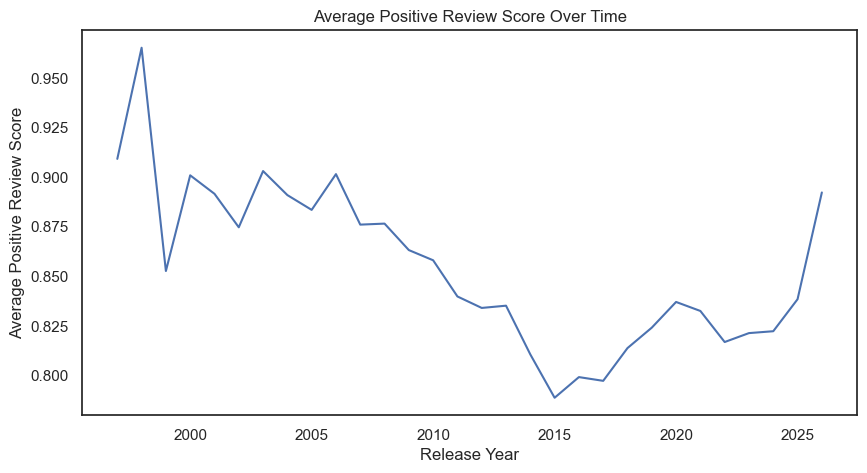

In [23]:
# Group the data by release year to calculate the average positive review score for each year
reviews_by_year = steam.groupby("release_year")["positive_ratio"].mean().reset_index()

# Create a new figure and set the size of the graph
plt.figure(figsize=(10, 5))

# Create a line graph
plt.plot(reviews_by_year["release_year"], reviews_by_year["positive_ratio"])

# Add a title to the graph
plt.title("Average Positive Review Score Over Time")

# Add a label for the x-axis
plt.xlabel("Release Year")

# Add a label for the y-axis
plt.ylabel("Average Positive Review Score")

# Save the graph as a PNG file
plt.savefig("Average Positive Review Score.png", dpi=300, bbox_inches="tight")

# Show the graph
plt.show()

# Graph 2: Average Positive Review Score by Price Group

In this graph I created group of price range to compare whether cheaper or more expensive games have higher average positive review scores.

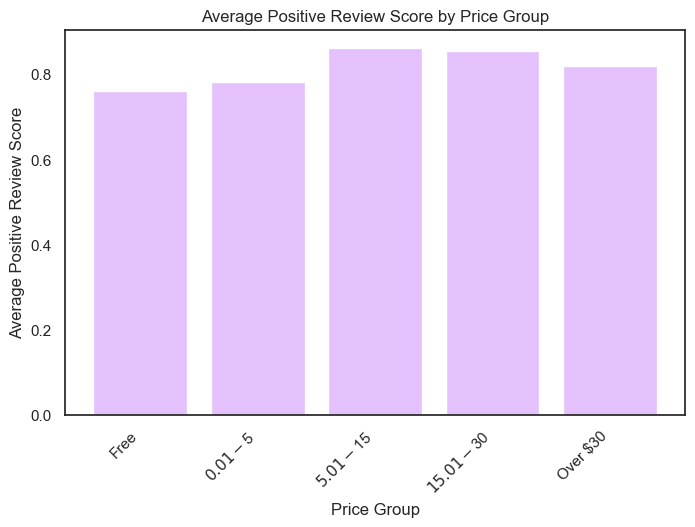

In [24]:
# Create a dollar price column
steam["price_usd"] = steam["price"] / 100

# Create a function that places each game price into a group
def price_group(price):
    
    # If the game is free, label it as "Free"
    if price == 0:
        return "Free"
    
    # If the game price is greater than 0 and less than or equal to $5
    elif price <= 5:
        return "$0.01-$5"
    
    # If the game price is greater than $5 and less than or equal to $15
    elif price <= 15:
        return "$5.01-$15"
    
    # If the game price is greater than $15 and less than or equal to $30
    elif price <= 30:
        return "$15.01-$30"
    
    # If the game price is greater than 30
    else:
        return "Over $30"

# Create a new column called price_group
steam["price_group"] = steam["price_usd"].apply(price_group)

# Group the data by price group
reviews_by_price = steam.groupby("price_group")["positive_ratio"].mean().reset_index()

# Create the correct order for the price groups
price_order = ["Free", "$0.01-$5", "$5.01-$15", "$15.01-$30", "Over $30"]

# Convert the price_group column into an ordered category
reviews_by_price["price_group"] = pd.Categorical(
    reviews_by_price["price_group"],
    categories=price_order,
    ordered=True)

# Sort the data based on the correct price group order
reviews_by_price = reviews_by_price.sort_values("price_group")

# Create a new figure and set the size of the graph
plt.figure(figsize=(8, 5))

# Create a bar graph with a color
plt.bar(
    reviews_by_price["price_group"], 
    reviews_by_price["positive_ratio"],
    color="#e4c0fc")

# Add a title to the graph
plt.title("Average Positive Review Score by Price Group")

# Add a label for the x-axis
plt.xlabel("Price Group")

# Add a label for the y-axis
plt.ylabel("Average Positive Review Score")

# Rotate the x-axis labels so they are easier to read
plt.xticks(rotation=45, ha="right")

# Save the graph as a PNG file
plt.savefig("Average Positive Review Score by Price Group.png", dpi=300, bbox_inches="tight")

# Show the graph
plt.show()

# Graph 3: Top 10 Genres by Average Positive Review Score 

In this graph it would show you which genres tend to receive higher positive review scores.

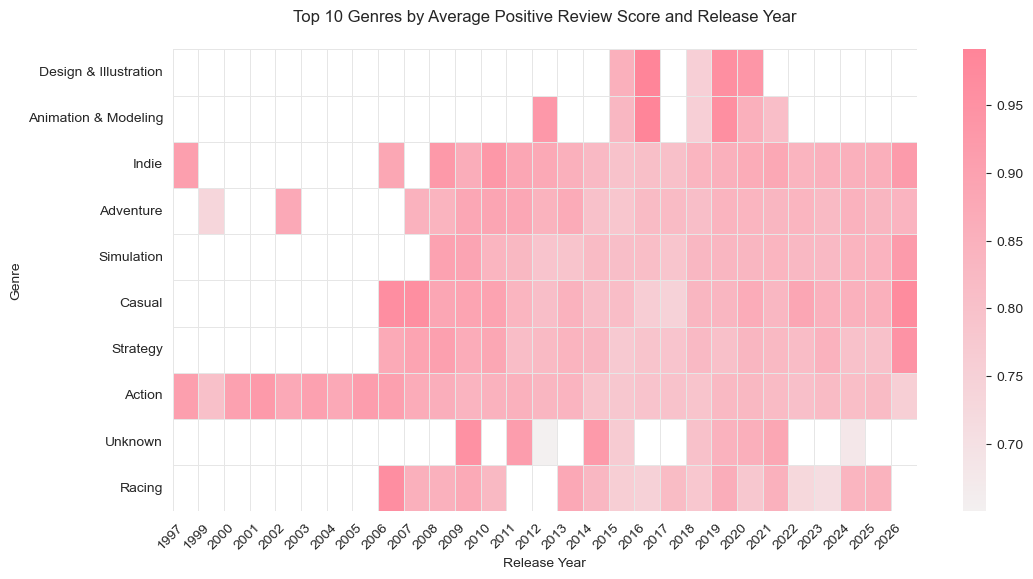

In [14]:
# Make a copy of the dataset so we do not change the original data
steam_genres = steam.copy()

# Remove rows where important columns are missing
steam_genres = steam_genres.dropna(subset=["genres", "release_year", "positive_ratio"])

# Split the genres column by comma
steam_genres["genres"] = steam_genres["genres"].str.split(", ")

# Explode is to separate the genres into their own rows
steam_genres = steam_genres.explode("genres")

# Remove extra spaces around genre names
steam_genres["genres"] = steam_genres["genres"].str.strip()

# Group by genre and calculate the average positive review score
genre_reviews = steam_genres.groupby("genres")["positive_ratio"].mean().reset_index()

# Count how many games are in each genre
genre_counts = steam_genres.groupby("genres")["name"].count().reset_index()
genre_counts = genre_counts.rename(columns={"name": "game_count"})

# Merge the average review score with the genre counts
genre_reviews = genre_reviews.merge(genre_counts, on="genres")

# Keep only genres that have at least 10 games
genre_reviews = genre_reviews[genre_reviews["game_count"] >= 10]

# Sort genres from highest average score to lowest
genre_reviews = genre_reviews.sort_values("positive_ratio", ascending=False)

# Keep the top 10 genres
top_genres = genre_reviews.head(10)

# Keep only those top 10 genres in the full exploded dataset
steam_genres = steam_genres[steam_genres["genres"].isin(top_genres["genres"])]

# Group by genre and release year and calculate average positive review score
genre_year_reviews = (
    steam_genres
    .groupby(["genres", "release_year"])["positive_ratio"]
    .mean()
    .reset_index()
)

# Create pivot table for heat map
hm = genre_year_reviews.pivot(
    index="genres",
    columns="release_year",
    values="positive_ratio")

# Reorder rows so they match the top 10 genre ranking
hm = hm.reindex(top_genres["genres"])

# Make the style cleaner
sns.set_style("white")

# Create heat map color palette
cmap = sns.light_palette("#ff8599", as_cmap=True)

# Create the figure
plt.figure(figsize=(12, 6), facecolor="white")

# Create heat map
ax = sns.heatmap(
    hm,
    cmap=cmap,
    linewidths=0.5,
    linecolor="#e6e6e6",
    cbar=True)

# Make plot background white
ax.set_facecolor("white")
plt.gcf().patch.set_facecolor("white")

# Add a title to the graph
plt.title("Top 10 Genres by Average Positive Review Score and Release Year", pad=20)

# Add a label for the x-axis
plt.xlabel("Release Year")

# Add a label for the y-axis
plt.ylabel("Genre")

# Rotate year labels
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

# Saving the graph
plt.savefig(
    "Top_10_Genres_Heat_Map.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white")

# Show graph
plt.show()

# Graph 4: Release Year vs. Positive Review Score 

The graph will show each year as a point and the trend line is there to help show whether or not the newer steam games are more likely to getting higher or lower positive review scores.

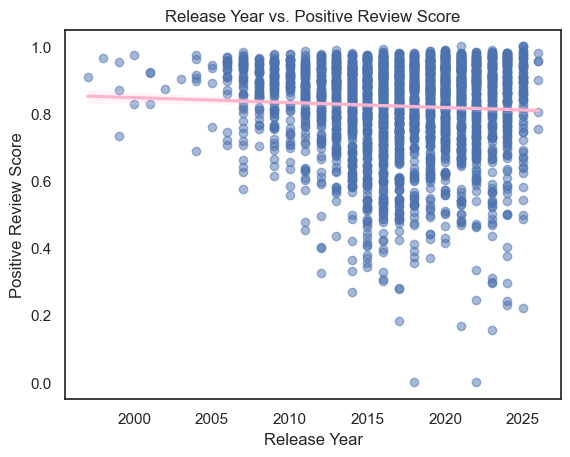

In [26]:
# Create a scatterplot with a regression trend line
# The x-axis is release year
# The y-axis is positive review score
sns.regplot(
    x="release_year",
    y="positive_ratio",
    data=steam,
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "#ffb3cc"})

# Add a title to the graph
plt.title("Release Year vs. Positive Review Score")

# Add a label for the x-axis
plt.xlabel("Release Year")

# Add a label for the y-axis
plt.ylabel("Positive Review Score")

# Save the graph as a PNG file
plt.savefig("Release Year vs. Positive Review Score.png", dpi=300, bbox_inches="tight")

# Display the graph
plt.show()